# Reto Parcial 1 - REHAB: Clasificacion de movimientos de rehabilitacion

**Equipo:** Angel Lugo, Jose Pablo, Juan Pablo

**Dataset:** REHAB - Rehab_exercise (16 movimientos de entrenamiento de rehabilitacion post-ACV)
Fuente: Lv et al. (2026), *Scientific Data* 13:1136. https://doi.org/10.57760/sciencedb.37018

**Objetivo de esta libreta (Etapa CRISP-DM: Comprension y preparacion de datos):**
1. Cargar y consolidar los `.npy` de los 16 movimientos.
2. Revisar forma, calidad y distribucion de clases.
3. Visualizar señales de ejemplo.
4. Documentar el hueco de datos conocido (movimiento 14) y dejar el dataset listo para modelado.

> **Nota:** el archivo oficial `014_1.npy` (canales IMU del movimiento "knee flexion and
> extension") esta corrupto en el repositorio publico de Science Data Bank -- se verifico que
> el MD5 descargado coincide con el publicado, asi que no es un error de descarga nuestro.
> Solo tenemos los canales del guante (`014_2.npy`) para ese movimiento.

## 1. Setup

In [1]:
# Si corres esto en Google Colab, descomenta para montar Drive y clonar el repo:
# from google.colab import drive
# drive.mount('/content/drive')
# !git clone https://github.com/<usuario>/<repo>.git
# %cd <repo>

import sys, os
sys.path.append(os.path.abspath('../src'))

import numpy as np
import matplotlib.pyplot as plt
from data_loader import build_dataset, MOVEMENT_NAMES

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Cargar el dataset consolidado

Coloca los `.npy` de `Rehab_exercise/d02_processed_data` (los 32 archivos, `000_1.npy` a
`015_2.npy`) dentro de la carpeta `data/` del repo. Para el movimiento `000`, usa la version
**procesada** (revisa el nombre del archivo en Science Data Bank; si descargaste dos copias
con hash en el nombre, la version procesada es la que tiene media cero).

In [2]:
DATA_DIR = "../data"

X, y, meta = build_dataset(DATA_DIR, incluir_mov14_parcial=False)
print("\nForma final:", X.shape, y.shape)

Dataset consolidado: X=(4257, 880, 12), y=(4257,)
Clases presentes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 15]
  mov 00 (bobath handshake): 232 muestras
  mov 01 (bobath flexion/extension): 212 muestras
  mov 02 (bobath forward flexion/extension): 267 muestras
  mov 03 (bobath anterior/posterior rotation): 250 muestras
  mov 04 (elbow flexion and wrist compression): 287 muestras
  mov 05 (wrist flexion and extension): 293 muestras
  mov 06 (finger-to-finger training): 260 muestras
  mov 07 (ball gripping): 385 muestras
  mov 08 (shoulder joint internal and external rotation): 299 muestras
  mov 09 (breast expansion): 307 muestras
  mov 10 (flexion-pressure rotation forward and backward): 311 muestras
  mov 11 (elbow joint flexion and touch): 235 muestras
  mov 12 (shoulder touch training): 293 muestras
  mov 13 (ankle extension & knee internal/external rotation): 313 muestras
  mov 14 (knee flexion and extension): 0 muestras  <-- SIN DATOS
  mov 15 (hip flexion and extension): 

## 3. Distribucion de clases

El paper reporta un dataset razonablemente balanceado (212 a 385 muestras por clase). Lo
confirmamos aqui, y vemos donde queda el hueco del movimiento 14 si se excluye.

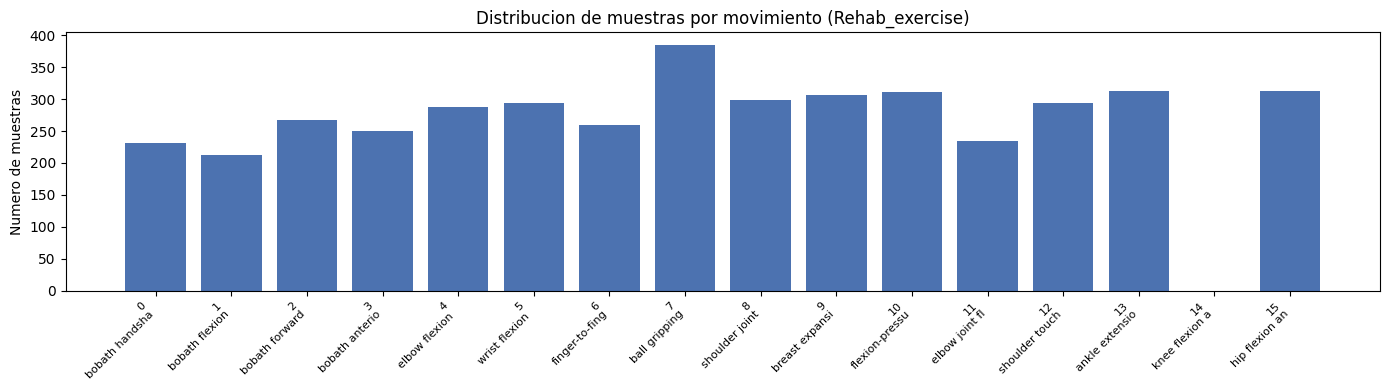

mov 00 - bobath handshake                             :  232 muestras
mov 01 - bobath flexion/extension                     :  212 muestras
mov 02 - bobath forward flexion/extension             :  267 muestras
mov 03 - bobath anterior/posterior rotation           :  250 muestras
mov 04 - elbow flexion and wrist compression          :  287 muestras
mov 05 - wrist flexion and extension                  :  293 muestras
mov 06 - finger-to-finger training                    :  260 muestras
mov 07 - ball gripping                                :  385 muestras
mov 08 - shoulder joint internal and external rotation:  299 muestras
mov 09 - breast expansion                             :  307 muestras
mov 10 - flexion-pressure rotation forward and backward:  311 muestras
mov 11 - elbow joint flexion and touch                :  235 muestras
mov 12 - shoulder touch training                      :  293 muestras
mov 13 - ankle extension & knee internal/external rotation:  313 muestras
mov 14 - knee f

In [3]:
counts = {mov: (y == mov).sum() for mov in range(16)}
labels = [f"{mov}\n{MOVEMENT_NAMES[mov][:14]}" for mov in counts]

plt.figure(figsize=(14, 4))
plt.bar(labels, counts.values(), color="#4C72B0")
plt.ylabel("Numero de muestras")
plt.title("Distribucion de muestras por movimiento (Rehab_exercise)")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

for mov, c in counts.items():
    flag = "  <-- excluido (dato corrupto en la fuente)" if c == 0 else ""
    print(f"mov {mov:02d} - {MOVEMENT_NAMES[mov]:45s}: {c:4d} muestras{flag}")

## 4. Visualizar señales de ejemplo

Cada muestra tiene 880 puntos de tiempo x 12 canales (6 IMU + 6 guante). Grafiquemos los
canales IMU de una muestra por clase para tener una primera intuicion de como se ven las
señales de movimientos distintos.

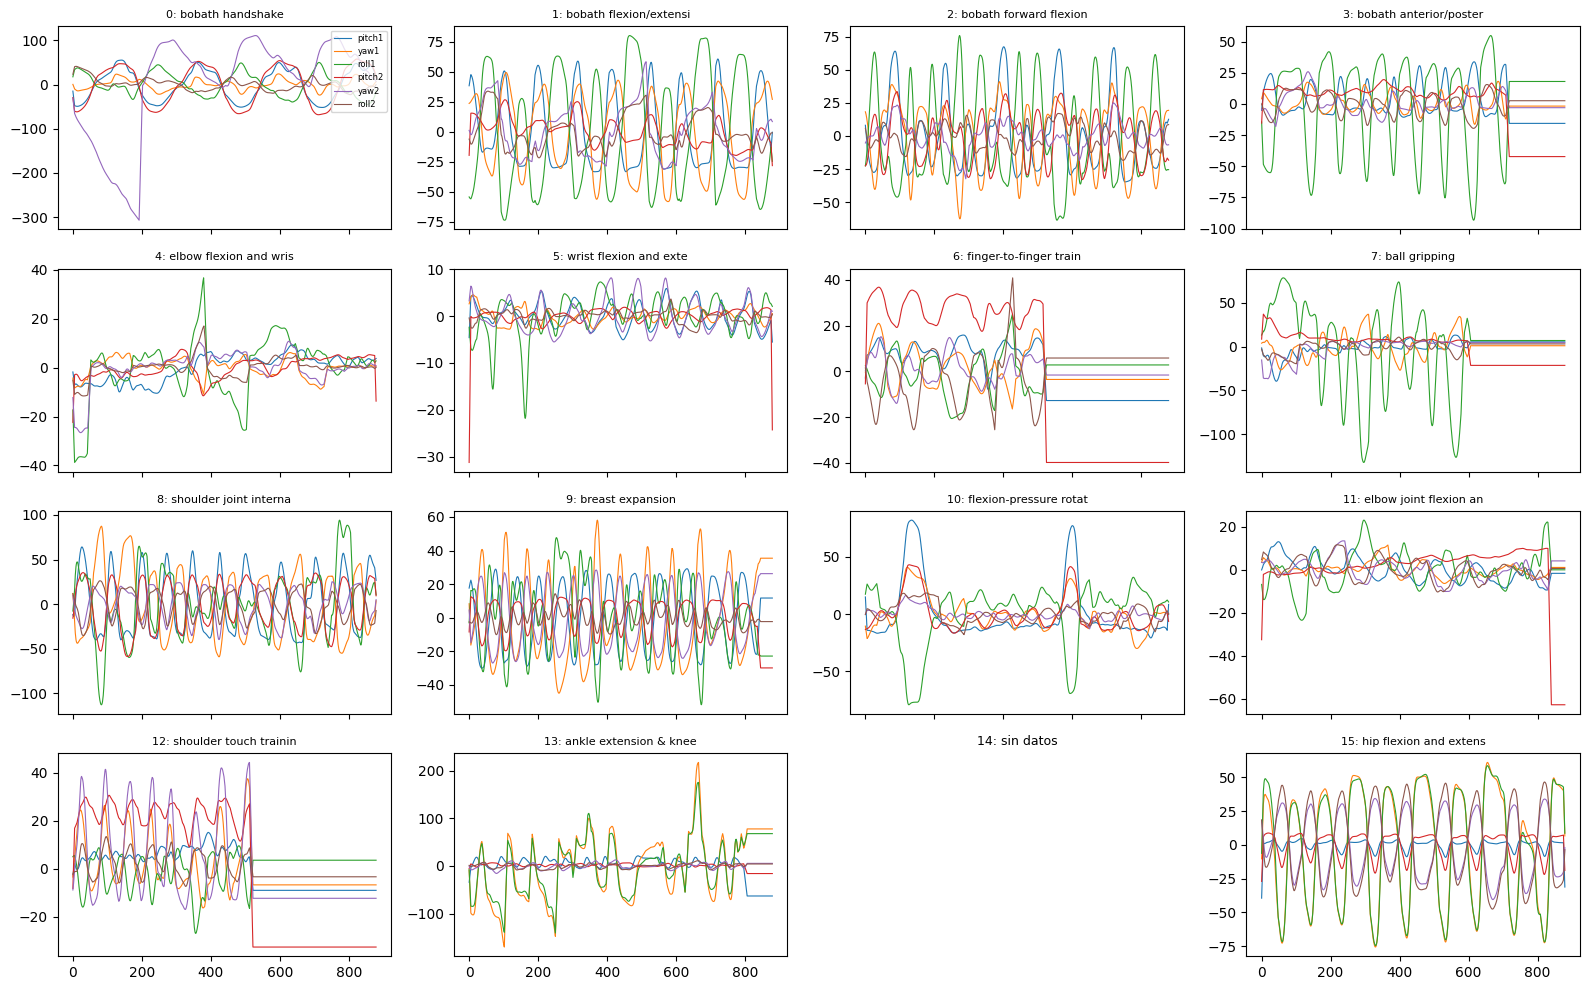

In [4]:
fig, axes = plt.subplots(4, 4, figsize=(16, 10), sharex=True)
imu_channel_names = ["pitch1", "yaw1", "roll1", "pitch2", "yaw2", "roll2"]

for ax, mov in zip(axes.flat, range(16)):
    idx = np.where(y == mov)[0]
    if len(idx) == 0:
        ax.set_title(f"{mov}: sin datos", fontsize=9)
        ax.axis("off")
        continue
    sample = X[idx[0]]
    for c in range(6):
        ax.plot(sample[:, c], linewidth=0.8, label=imu_channel_names[c])
    ax.set_title(f"{mov}: {MOVEMENT_NAMES[mov][:22]}", fontsize=8)

axes.flat[0].legend(fontsize=6, loc="upper right")
plt.tight_layout()
plt.show()

## 5. Chequeos de calidad de datos

Antes de pasar a la etapa de modelado, dejamos constancia de:
- Que no haya NaN/Inf en el set principal (sin el movimiento 14 parcial).
- El desbalance real entre clases (razon max/min de muestras).
- El hueco de datos del movimiento 14, para discutirlo en el reporte del equipo.

In [ ]:
print("NaN en X:", np.isnan(X).sum())
print("Inf en X:", np.isinf(X).sum())

vals = np.array(list(counts.values()))
vals_validas = vals[vals > 0]
print(f"Muestras por clase -> min={vals_validas.min()}, max={vals_validas.max()}, "
      f"razon max/min={vals_validas.max()/vals_validas.min():.2f}")

print("\nClases con datos:", sorted(set(y.tolist())))
print("Clases SIN datos (excluidas):", [m for m, c in counts.items() if c == 0])

## 6. Guardar dataset consolidado

Guardamos `X`, `y` en un solo `.npz` para que el resto del equipo no tenga que repetir la
carga/consolidacion en la siguiente etapa (modelado).

In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)
np.savez_compressed("../data/processed/rehab_exercise_consolidado.npz", X=X, y=y)
print("Guardado en ../data/processed/rehab_exercise_consolidado.npz")

## Siguientes pasos (equipo)

1. **Preprocesamiento:** decidir si se trabaja con la señal cruda (880 x 12) o con
   features agregadas (amplitud, RMS, frecuencia, como en el paper) para modelos clasicos.
2. **Split:** train / validation / test (por ejemplo 70/15/15), estratificado por clase.
3. **Modelo base:** empezar simple (RandomForest o SVM sobre features) antes de ir a
   1D-CNN / LSTM sobre la señal cruda.
4. **Manejo del movimiento 14:** decidir en equipo si se excluye del modelo, se reporta
   aparte, o se intenta clasificar solo con los 6 canales del guante disponibles.
5. **Desbalance de clases:** revisar si razon max/min amerita balanceo (class_weight,
   oversampling, etc.).